<a href="https://colab.research.google.com/github/JennyDiones/ITELEC2_PROJECT/blob/DIONES/Chapter_9_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
summary = pd.DataFrame({
    "Metric": ["Total Transactions", "Min Support", "Min Confidence",
               "Frequent Itemsets Found", "Association Rules Generated"],
    "Value": [transactions.count(), 0.05, 0.4, freq.count(), rules.count()]
})

print("=== FP-Growth Results Summary ===")
display(summary.style.hide(axis="index").set_caption("Model Summary"))

=== FP-Growth Results Summary ===


Metric,Value
Total Transactions,8235082.000000
Min Support,0.050000
Min Confidence,0.400000
Frequent Itemsets Found,21.000000
Association Rules Generated,1.000000


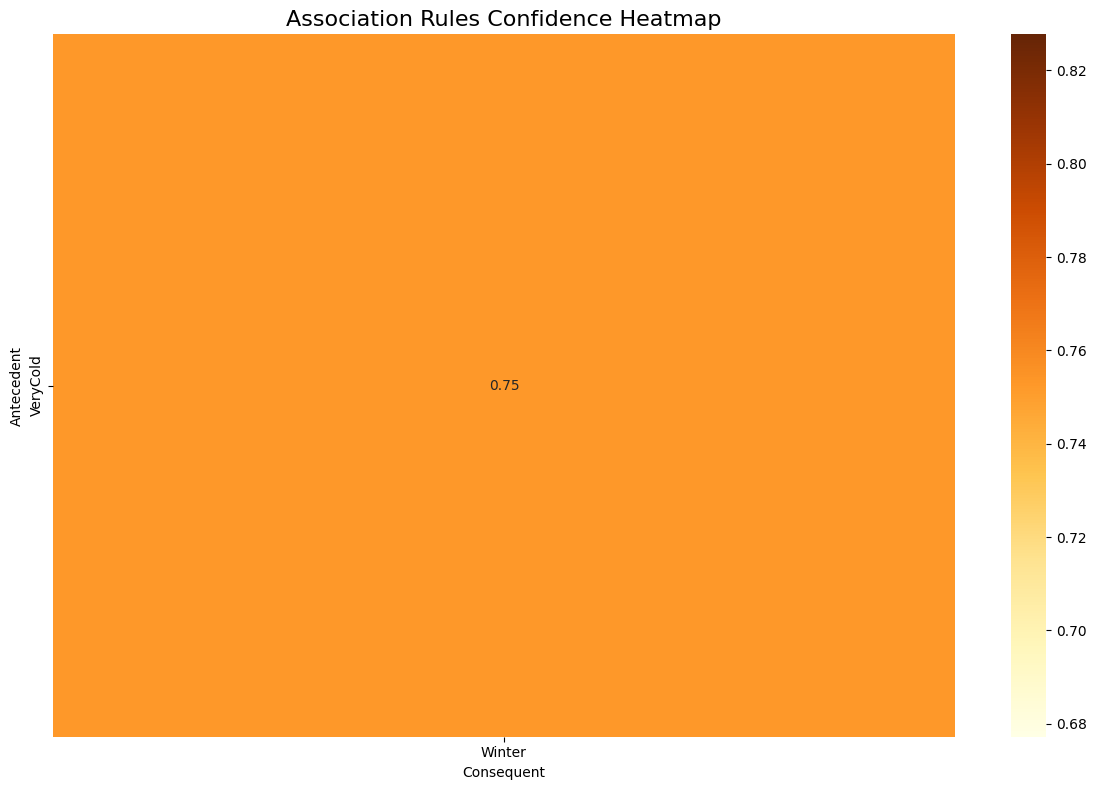

In [ ]:
plt.figure(figsize=(12, 8))
top_rules = rules_pd.nlargest(20, 'confidence')
top_rules['rule'] = top_rules['antecedent_str'] + " → " + top_rules['consequent_str']

pivot = top_rules.pivot_table(index='antecedent_str',
                             columns='consequent_str',
                             values='confidence', fill_value=0)

sns.heatmap(pivot, annot=True, cmap='YlOrBr', fmt='.2f')
plt.title('Association Rules Confidence Heatmap', fontsize=16)
plt.ylabel('Antecedent')
plt.xlabel('Consequent')
plt.tight_layout()
plt.show()

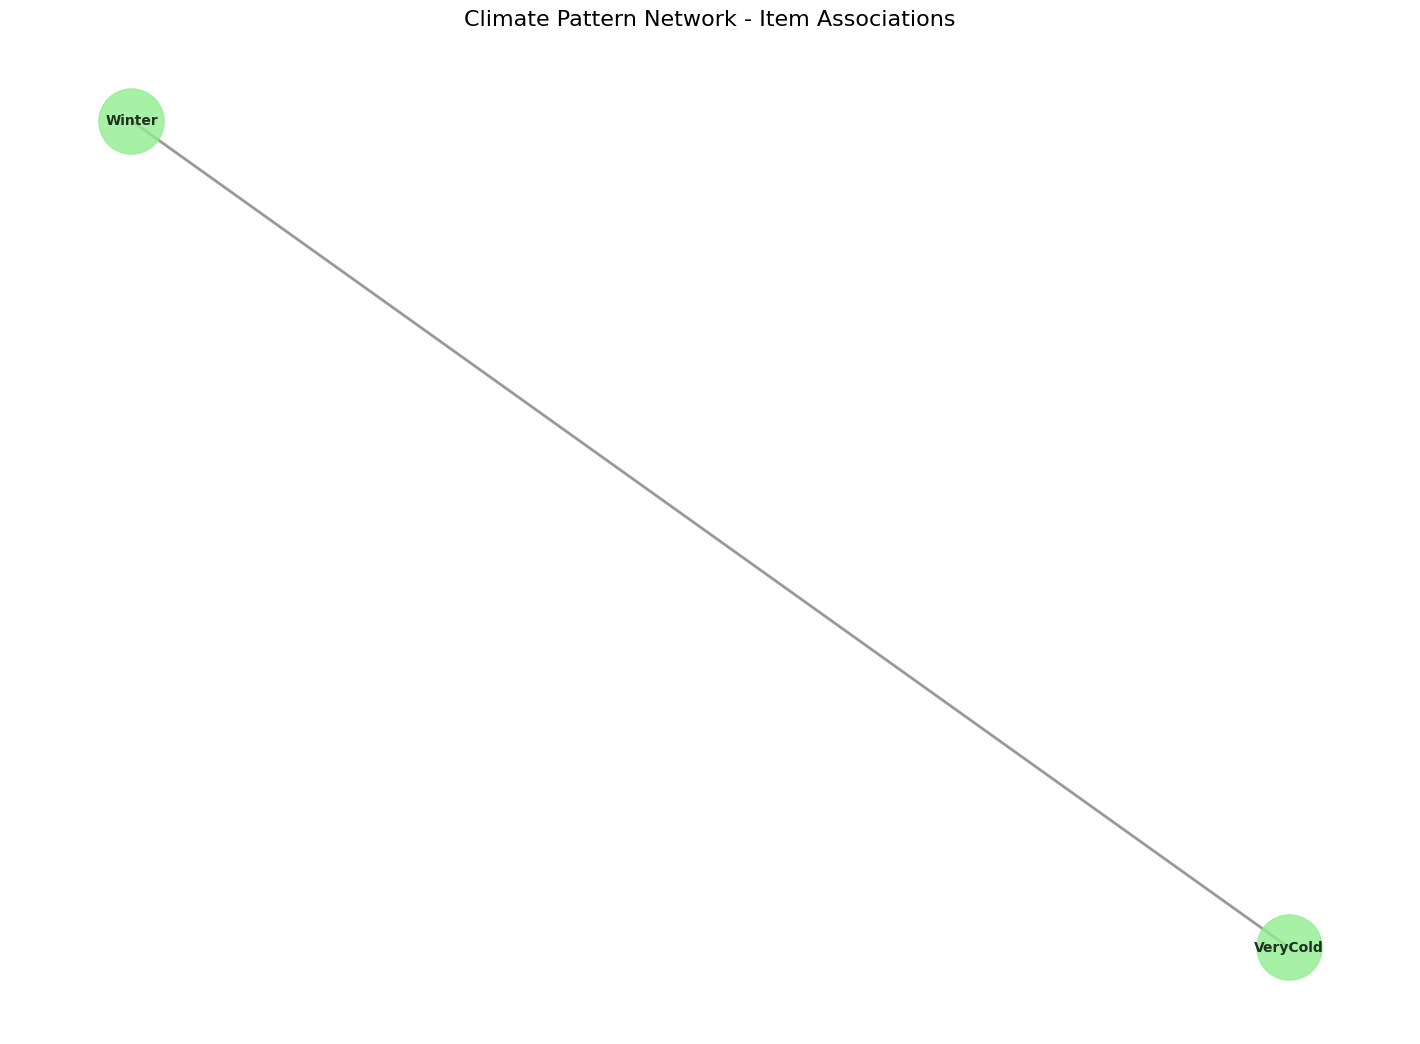

In [ ]:
plt.figure(figsize=(14, 10))
G = nx.Graph()

for _, row in rules_pd.head(25).iterrows():
    for a in row['antecedent']:
        for c in row['consequent']:
            G.add_edge(a, c, weight=row['lift'])

pos = nx.spring_layout(G, k=0.6)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=2200,
        font_size=10, font_weight='bold', edge_color='gray', width=2, alpha=0.8)
plt.title("Climate Pattern Network - Item Associations", fontsize=16)
plt.show()

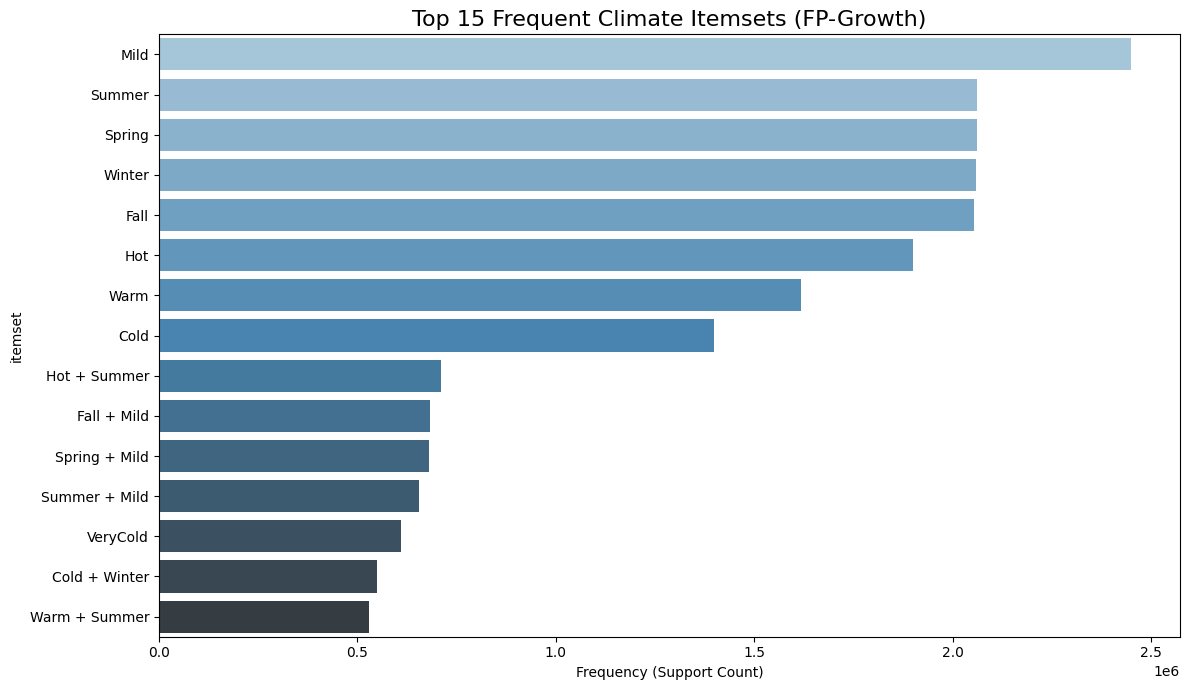

In [ ]:
plt.figure(figsize=(12, 7))
top15 = freq_pd.head(15)
sns.barplot(data=top15, y='itemset', x='freq', palette='Blues_d')
plt.title('Top 15 Frequent Climate Itemsets (FP-Growth)', fontsize=16)
plt.xlabel('Frequency (Support Count)')
plt.tight_layout()
plt.show()

In [ ]:
freq_pd = freq.toPandas()
rules_pd = rules.toPandas()

# Clean strings
freq_pd['itemset'] = freq_pd['items'].apply(lambda x: ' + '.join(x))
rules_pd['antecedent_str'] = rules_pd['antecedent'].apply(lambda x: ' + '.join(x))
rules_pd['consequent_str'] = rules_pd['consequent'].apply(lambda x: ' + '.join(x))

In [ ]:
fp = FPGrowth(itemsCol="items", minSupport=0.05, minConfidence=0.4)

model = fp.fit(transactions)

# Frequent Itemsets
freq = model.freqItemsets.orderBy("freq", ascending=False)
freq.show(20, truncate=False)

# Association Rules
rules = model.associationRules.orderBy("lift", ascending=False)
rules.show(15, truncate=False)

+------------------+-------+
|items             |freq   |
+------------------+-------+
|[Mild]            |2449693|
|[Summer]          |2061598|
|[Spring]          |2060819|
|[Winter]          |2059515|
|[Fall]            |2053150|
|[Hot]             |1898487|
|[Warm]            |1617011|
|[Cold]            |1398109|
|[Hot, Summer]     |710917 |
|[Fall, Mild]      |683013 |
|[Spring, Mild]    |680365 |
|[Summer, Mild]    |655867 |
|[VeryCold]        |611080 |
|[Cold, Winter]    |549857 |
|[Warm, Summer]    |528125 |
|[Hot, Fall]       |479026 |
|[VeryCold, Winter]|459831 |
|[Hot, Spring]     |446066 |
|[Cold, Spring]    |438362 |
|[Warm, Fall]      |437622 |
+------------------+-------+
only showing top 20 rows
+----------+----------+------------------+-----------------+-------------------+
|antecedent|consequent|confidence        |lift             |support            |
+----------+----------+------------------+-----------------+-------------------+
|[VeryCold]|[Winter]  |0.75248903580

In [ ]:
# Load the dataset
df = spark.read.csv(list(uploaded.keys())[0], header=True, inferSchema=True)

# Basic cleaning
df = df.dropna(subset=['AverageTemperature'])
df = df.withColumn("Month", month("dt"))
df = df.withColumn("Year", year("dt"))

# Create categorical items
df = df.withColumn("Temp_Level",
    when(col("AverageTemperature") < 0, "VeryCold")
    .when(col("AverageTemperature") < 10, "Cold")
    .when(col("AverageTemperature") < 20, "Mild")
    .when(col("AverageTemperature") < 25, "Warm")
    .when(col("AverageTemperature") < 30, "Hot")
    .otherwise("VeryHot"))

df = df.withColumn("Season",
    when(col("Month").isin(12,1,2), "Winter")
    .when(col("Month").isin(3,4,5), "Spring")
    .when(col("Month").isin(6,7,8), "Summer")
    .otherwise("Fall"))

# Create transaction items
items_udf = udf(lambda t, s: [t, s], ArrayType(StringType()))

transactions = df.withColumn("items", items_udf(col("Temp_Level"), col("Season"))) \
                 .select("items")

print(f"Total climate transactions created: {transactions.count()}")
transactions.show(10, truncate=False)

Total climate transactions created: 8235082
+------------------+
|items             |
+------------------+
|[Cold, Fall]      |
|[Cold, Spring]    |
|[Mild, Spring]    |
|[Mild, Summer]    |
|[Mild, Summer]    |
|[Mild, Fall]      |
|[Cold, Fall]      |
|[Cold, Fall]      |
|[Cold, Winter]    |
|[VeryCold, Winter]|
+------------------+
only showing top 10 rows


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving GlobalLandTemperaturesByCity.csv to GlobalLandTemperaturesByCity.csv


In [ ]:
!pip install pyspark pandas matplotlib seaborn networkx -q

from pyspark.sql import SparkSession
from pyspark.ml.fpm import FPGrowth
from pyspark.sql.functions import col, when, udf, month, year, split
from pyspark.sql.types import ArrayType, StringType
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

spark = SparkSession.builder.appName("FP-Growth on Global Temperatures - Chapter 9").getOrCreate()
print(" Spark Ready!")

✅ Spark Ready!
